# Q2: Attention-Enhanced GAN
### Self-Attention + Cross-Attention to improve text-to-image generation

**What attention adds:**
- **Self-Attention**: Generator's feature map attends to itself → global spatial consistency
- **Cross-Attention**: Generator attends to text embedding at every spatial location → better text alignment

```
Text Embedding → Cross-Attention → Generator Features → Self-Attention → Image
```

In [2]:
# CELL 1: Install Dependencies
!pip install gradio torch torchvision transformers matplotlib numpy Pillow diffusers peft scikit-learn -q
print('Dependencies installed!')

Dependencies installed!


In [1]:
# CELL 2: Imports & Config
import torch
import transformers
import gradio
import torch.nn as nn # Added explicit import for nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTokenizer, CLIPTextModel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image, ImageDraw
import gradio as gr
import re
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 64
LATENT_DIM = 100
EMBED_DIM  = 512
PROJ_DIM   = 128
NUM_HEADS  = 4
NUM_CLASS  = 3
BATCH_SIZE = 64
EPOCHS     = 60
LR         = 0.0002
BETA1      = 0.5
MAX_TOKENS = 77
CLIP_MODEL = 'openai/clip-vit-base-patch32'
LABELS     = ['circle', 'square', 'triangle']

print(f'Device    : {DEVICE}')
print(f'Attention : {NUM_HEADS} heads')
print('Imports done!')

Device    : cuda
Attention : 4 heads
Imports done!


In [2]:
# CELL 3: Text Preprocessing (same as Q1/Q5)
def preprocess_text(text: str) -> str:
    if not text or not text.strip():
        raise ValueError('Empty text')
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s,.\'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if len(text) > 200:
        text = text[:200].rsplit(' ', 1)[0]
    return text

def extract_shape_label(text: str) -> int:
    text_lower = text.lower()
    keywords = {
        0: ['circle','round','circular','oval','disc','ball','curved','sphere'],
        1: ['square','box','cube','rectangle','rectangular','block','quadrilateral'],
        2: ['triangle','triangular','pyramid','cone','wedge','angular','pointed']
    }
    scores = {k: sum(1 for w in v if w in text_lower) for k, v in keywords.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 0

print('Text preprocessing ready!')

Text preprocessing ready!


In [4]:
# CELL 4: Load CLIP
print('Loading CLIP (~500MB first run)...')
tokenizer    = CLIPTokenizer.from_pretrained(CLIP_MODEL)
text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL).to(DEVICE)
text_encoder.eval()

def get_text_embedding(text: str) -> np.ndarray:
    cleaned = preprocess_text(text)
    tokens  = tokenizer(cleaned, padding='max_length', max_length=MAX_TOKENS,
                        truncation=True, return_tensors='pt')
    tokens  = {k: v.to(DEVICE) for k, v in tokens.items()}
    with torch.no_grad():
        out = text_encoder(**tokens)
    return out.pooler_output.squeeze(0).cpu().numpy()

test_emb = get_text_embedding('a smooth circular disc')
print(f'CLIP ready! Embedding shape: {test_emb.shape}')

Loading CLIP (~500MB first run)...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.post_layernorm.weight                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.l

CLIP ready! Embedding shape: (512,)


In [5]:
# CELL 5: Attention Modules

class SelfAttention(nn.Module):
    """
    Self-Attention on spatial feature maps.
    Each spatial position attends to ALL other positions.
    Lets the generator maintain global consistency —
    e.g. the left side of a circle knows what the right side looks like.

    Input : (B, C, H, W) feature map
    Output: (B, C, H, W) attended feature map
    """
    def __init__(self, channels: int, num_heads: int = 4):
        super().__init__()
        self.channels  = channels
        self.num_heads = num_heads
        self.norm      = nn.GroupNorm(8, channels)
        self.attn      = nn.MultiheadAttention(
            embed_dim=channels, num_heads=num_heads,
            batch_first=True
        )
        self.proj_out  = nn.Conv2d(channels, channels, 1)
        self.gamma     = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape
        residual    = x
        x_norm      = self.norm(x)

        x_flat      = x_norm.view(B, C, H*W).permute(0, 2, 1)

        attn_out, _ = self.attn(x_flat, x_flat, x_flat)

        attn_out    = attn_out.permute(0, 2, 1).view(B, C, H, W)
        attn_out    = self.proj_out(attn_out)

        return residual + self.gamma * attn_out


class CrossAttention(nn.Module):
    """
    Cross-Attention between image features and text embedding.
    Each spatial position in the feature map attends to the text.
    This is how the generator 'reads' the text while drawing.

    Input : x (B, C, H, W) image features
            text_emb (B, PROJ_DIM) text condition
    Output: (B, C, H, W) text-attended features
    """
    def __init__(self, channels: int, text_dim: int, num_heads: int = 4):
        super().__init__()
        self.norm_img  = nn.GroupNorm(8, channels)
        self.norm_text = nn.LayerNorm(text_dim)

        self.text_proj = nn.Linear(text_dim, channels)
        self.attn      = nn.MultiheadAttention(
            embed_dim=channels, num_heads=num_heads,
            batch_first=True
        )
        self.proj_out  = nn.Conv2d(channels, channels, 1)
        self.gamma     = nn.Parameter(torch.zeros(1))

    def forward(self, x, text_emb):
        B, C, H, W = x.shape
        residual    = x
        x_norm      = self.norm_img(x)

        queries     = x_norm.view(B, C, H*W).permute(0, 2, 1)

        text_norm   = self.norm_text(text_emb)
        text_proj   = self.text_proj(text_norm).unsqueeze(1)

        attn_out, _ = self.attn(queries, text_proj, text_proj)
        attn_out    = attn_out.permute(0, 2, 1).view(B, C, H, W)
        attn_out    = self.proj_out(attn_out)
        return residual + self.gamma * attn_out


class AttentionBlock(nn.Module):
    """
    Combined block: CrossAttention → SelfAttention
    Used inside the Generator at multiple scales.
    """
    def __init__(self, channels: int, text_dim: int, num_heads: int = 4):
        super().__init__()
        self.cross_attn = CrossAttention(channels, text_dim, num_heads)
        self.self_attn  = SelfAttention(channels, num_heads)

    def forward(self, x, text_emb):
        x = self.cross_attn(x, text_emb)
        x = self.self_attn(x)
        return x

print('Attention modules defined!')
print('  SelfAttention  : spatial positions attend to each other')
print('  CrossAttention : spatial positions attend to text embedding')
print('  AttentionBlock : Cross → Self (used inside generator)')

Attention modules defined!
  SelfAttention  : spatial positions attend to each other
  CrossAttention : spatial positions attend to text embedding
  AttentionBlock : Cross → Self (used inside generator)


In [6]:
# CELL 6: Attention GAN Architecture

class TextProjection(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(EMBED_DIM, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, PROJ_DIM),  nn.LayerNorm(PROJ_DIM), nn.GELU()
        )
    def forward(self, x):
        return self.net(x)


class AttentionGenerator(nn.Module):
    """
    Generator with AttentionBlocks inserted at 16x16 and 32x32 scales.
    Why those scales? Large spatial maps (32x32+) are expensive.
    Mid scales (16x16) give best quality/cost tradeoff.
    """
    def __init__(self):
        super().__init__()
        self.text_proj = TextProjection()

        self.fc = nn.Sequential(
            nn.Linear(LATENT_DIM + PROJ_DIM, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4), nn.ReLU(True)
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(True)
        )

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(True)
        )
        self.attn1 = AttentionBlock(channels=64, text_dim=PROJ_DIM, num_heads=NUM_HEADS)


        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(True)
        )
        self.attn2 = AttentionBlock(channels=32, text_dim=PROJ_DIM, num_heads=NUM_HEADS)


        self.up4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_emb):
        proj = self.text_proj(text_emb)
        x    = torch.cat([noise, proj], dim=1)
        x    = self.fc(x).view(-1, 256, 4, 4)
        x    = self.up1(x)
        x    = self.up2(x)
        x    = self.attn1(x, proj)
        x    = self.up3(x)
        x    = self.attn2(x, proj)
        return self.up4(x)


class AttentionDiscriminator(nn.Module):
    """
    Discriminator with SelfAttention at 16x16 scale.
    Helps discriminator spot global structural inconsistencies.
    """
    def __init__(self):
        super().__init__()
        self.text_proj = TextProjection()
        self.down1 = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2, True)
        )
        self.down2 = nn.Sequential(
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True)
        )
        self.self_attn = SelfAttention(channels=64, num_heads=NUM_HEADS)
        self.down3 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True)
        )
        self.down4 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4 + PROJ_DIM, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, images, text_emb):
        x         = self.down1(images)
        x         = self.down2(x)
        x         = self.self_attn(x)              # SelfAttn at 16x16
        x         = self.down3(x)
        x         = self.down4(x)
        img_feat  = x.view(x.size(0), -1)
        text_feat = self.text_proj(text_emb)
        return self.fc(torch.cat([img_feat, text_feat], dim=1))


G = AttentionGenerator().to(DEVICE)
D = AttentionDiscriminator().to(DEVICE)

opt_G     = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D     = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
criterion = nn.BCELoss()

print(f'AttentionGenerator params     : {sum(p.numel() for p in G.parameters()):,}')
print(f'AttentionDiscriminator params : {sum(p.numel() for p in D.parameters()):,}')
print('Attention GAN ready!')

AttentionGenerator params     : 1,865,925
AttentionDiscriminator params : 3,039,650
Attention GAN ready!


In [7]:
# CELL 7: Dataset + Pre-compute Embeddings

SHAPE_TEMPLATES = {
    0: ['a smooth circular shape with rounded edges',
        'a perfect circle with curved boundaries',
        'a round disc with uniform smooth edges',
        'a circular form with no corners or angles'],
    1: ['a square shape with four equal sides',
        'a rectangular box with sharp right angles',
        'a geometric square with straight edges and corners',
        'a block shape with four sharp corners'],
    2: ['a triangle with three pointed vertices',
        'a triangular pyramid with angular edges',
        'a three-sided shape pointing upward',
        'a wedge-shaped triangle with sharp tip']
}

class TextShapeDataset(Dataset):
    def __init__(self, num_samples=4000, img_size=64):
        self.num_samples = num_samples
        self.img_size    = img_size
        self.data        = [i % NUM_CLASS for i in range(num_samples)]

    def _draw_shape(self, label_idx):
        img  = Image.new('L', (self.img_size, self.img_size), color=0)
        draw = ImageDraw.Draw(img)
        s, pad = self.img_size, self.img_size // 6
        if label_idx == 0:
            draw.ellipse([pad, pad, s-pad, s-pad], fill=255)
        elif label_idx == 1:
            draw.rectangle([pad, pad, s-pad, s-pad], fill=255)
        elif label_idx == 2:
            draw.polygon([(s//2, pad), (pad, s-pad), (s-pad, s-pad)], fill=255)
        arr = np.array(img, dtype=np.float32) / 127.5 - 1.0
        return torch.tensor(arr).unsqueeze(0)

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        label = self.data[idx]
        return self._draw_shape(label), torch.tensor(label, dtype=torch.long), random.choice(SHAPE_TEMPLATES[label])


dataset = TextShapeDataset()
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print('Pre-computing CLIP embeddings...')
TEMPLATE_EMBEDDINGS = {}
for label_idx, texts in SHAPE_TEMPLATES.items():
    TEMPLATE_EMBEDDINGS[label_idx] = np.array([get_text_embedding(t) for t in texts])
    print(f'  {LABELS[label_idx]}: done')

def get_batch_embeddings(labels_tensor):
    batch_embs = []
    for lbl in labels_tensor.cpu().numpy():
        embs = TEMPLATE_EMBEDDINGS[lbl]
        batch_embs.append(embs[np.random.randint(len(embs))])
    return torch.tensor(np.array(batch_embs), dtype=torch.float32).to(DEVICE)

print('Dataset + embeddings ready!')

Pre-computing CLIP embeddings...
  circle: done
  square: done
  triangle: done
Dataset + embeddings ready!


Training Attention GAN for 60 epochs on cuda...
Expected: ~10-15 min on T4 (attention adds compute)
Epoch [10/60]  G: 8.8605  D: 0.0001


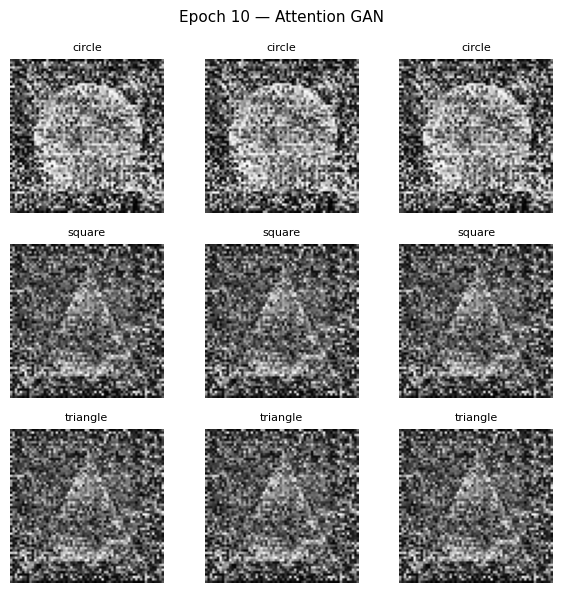

Epoch [20/60]  G: 10.2189  D: 0.0000


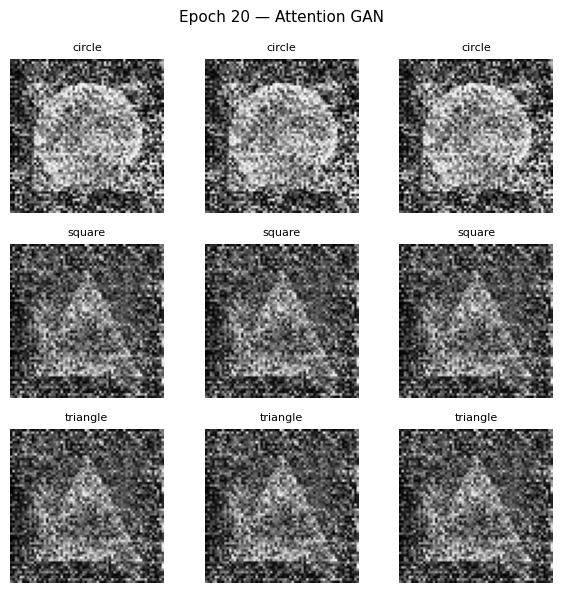

Epoch [30/60]  G: 11.0295  D: 0.0000


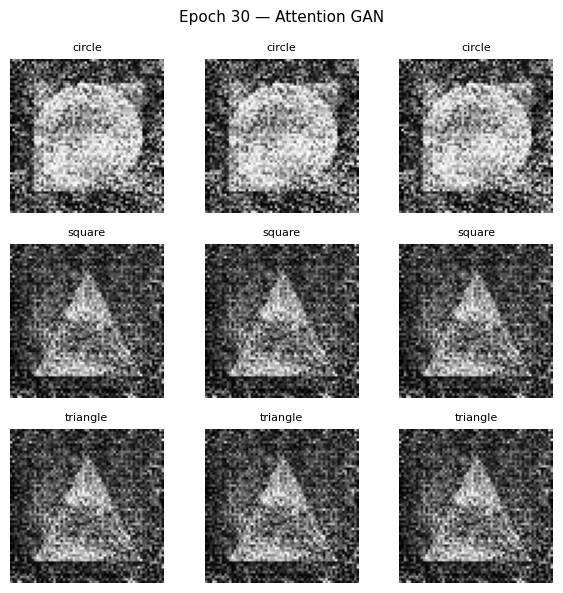

Epoch [40/60]  G: 0.0000  D: 50.0000


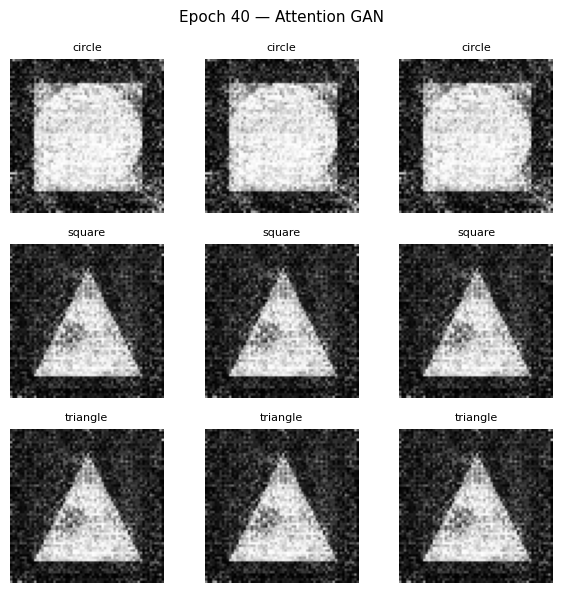

Epoch [50/60]  G: 0.0000  D: 50.0000


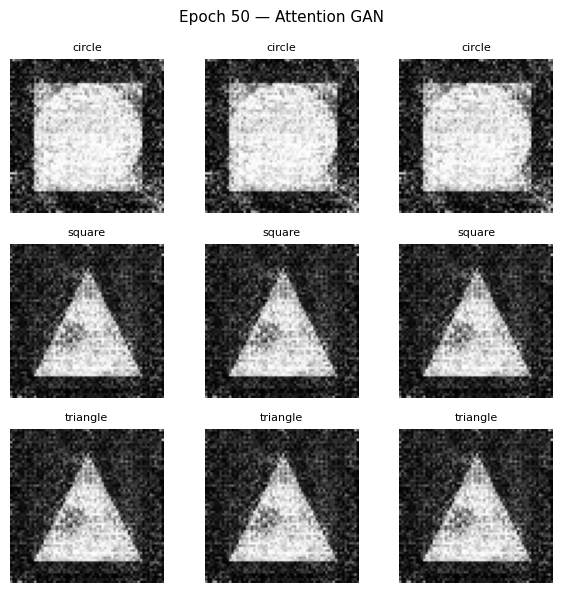

Epoch [60/60]  G: 0.0000  D: 50.0000


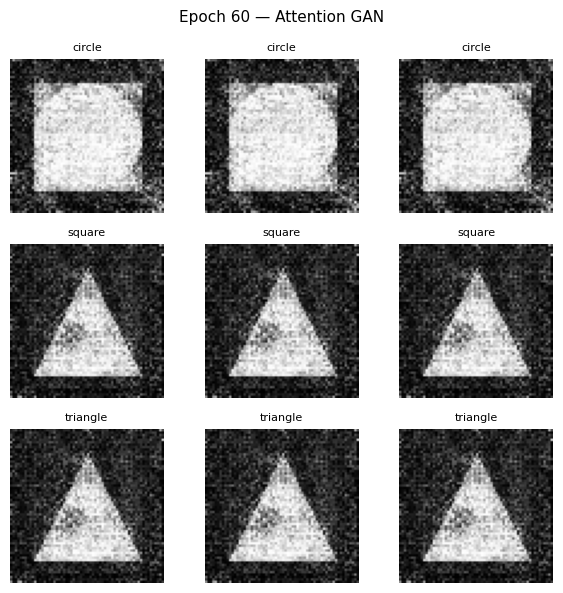

Training Complete!


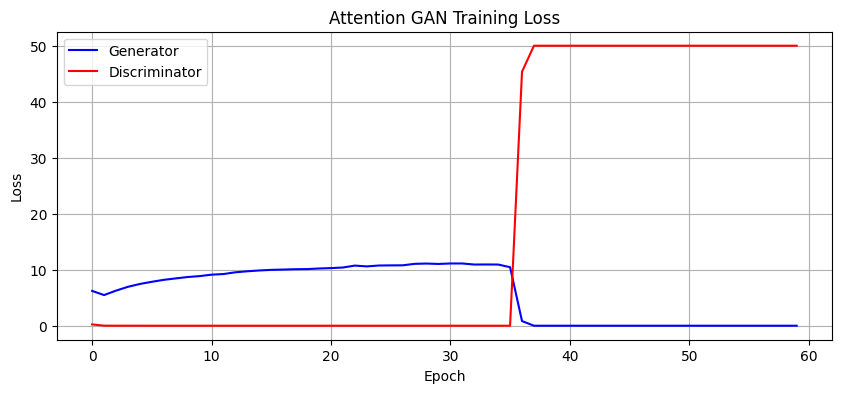

In [8]:
# CELL 8: Training Loop
G_losses, D_losses = [], []

fixed_noise  = torch.randn(9, LATENT_DIM).to(DEVICE)
fixed_labels = torch.tensor([0,0,0,1,1,1,2,2,2])
fixed_embs   = get_batch_embeddings(fixed_labels)

print(f'Training Attention GAN for {EPOCHS} epochs on {DEVICE}...')
print('Expected: ~10-15 min on T4 (attention adds compute)')
print('='*60)

for epoch in range(EPOCHS):
    epoch_g, epoch_d = 0, 0

    for real_imgs, labels, texts in loader:
        real_imgs = real_imgs.to(DEVICE)
        labels    = labels.to(DEVICE)
        B         = real_imgs.size(0)
        text_embs = get_batch_embeddings(labels)
        real_t    = torch.ones(B, 1).to(DEVICE)
        fake_t    = torch.zeros(B, 1).to(DEVICE)


        opt_D.zero_grad()
        loss_real = criterion(D(real_imgs, text_embs), real_t)
        noise     = torch.randn(B, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, text_embs)
        loss_fake = criterion(D(fake_imgs.detach(), text_embs), fake_t)
        loss_D    = (loss_real + loss_fake) / 2
        loss_D.backward()
        opt_D.step()


        opt_G.zero_grad()
        noise     = torch.randn(B, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, text_embs)
        loss_G    = criterion(D(fake_imgs, text_embs), real_t)
        loss_G.backward()
        opt_G.step()

        epoch_g += loss_G.item()
        epoch_d += loss_D.item()

    avg_g = epoch_g / len(loader)
    avg_d = epoch_d / len(loader)
    G_losses.append(avg_g)
    D_losses.append(avg_d)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}]  G: {avg_g:.4f}  D: {avg_d:.4f}')
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise, fixed_embs).cpu()
        G.train()
        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        for i in range(9):
            axes[i//3][i%3].imshow(samples[i].squeeze(), cmap='gray')
            axes[i//3][i%3].set_title(LABELS[fixed_labels[i].item()], fontsize=8)
            axes[i//3][i%3].axis('off')
        plt.suptitle(f'Epoch {epoch+1} — Attention GAN', fontsize=11)
        plt.tight_layout()
        plt.show()

print('Training Complete!')

plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator', color='blue')
plt.plot(D_losses, label='Discriminator', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Attention GAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()

Generating comparison samples...


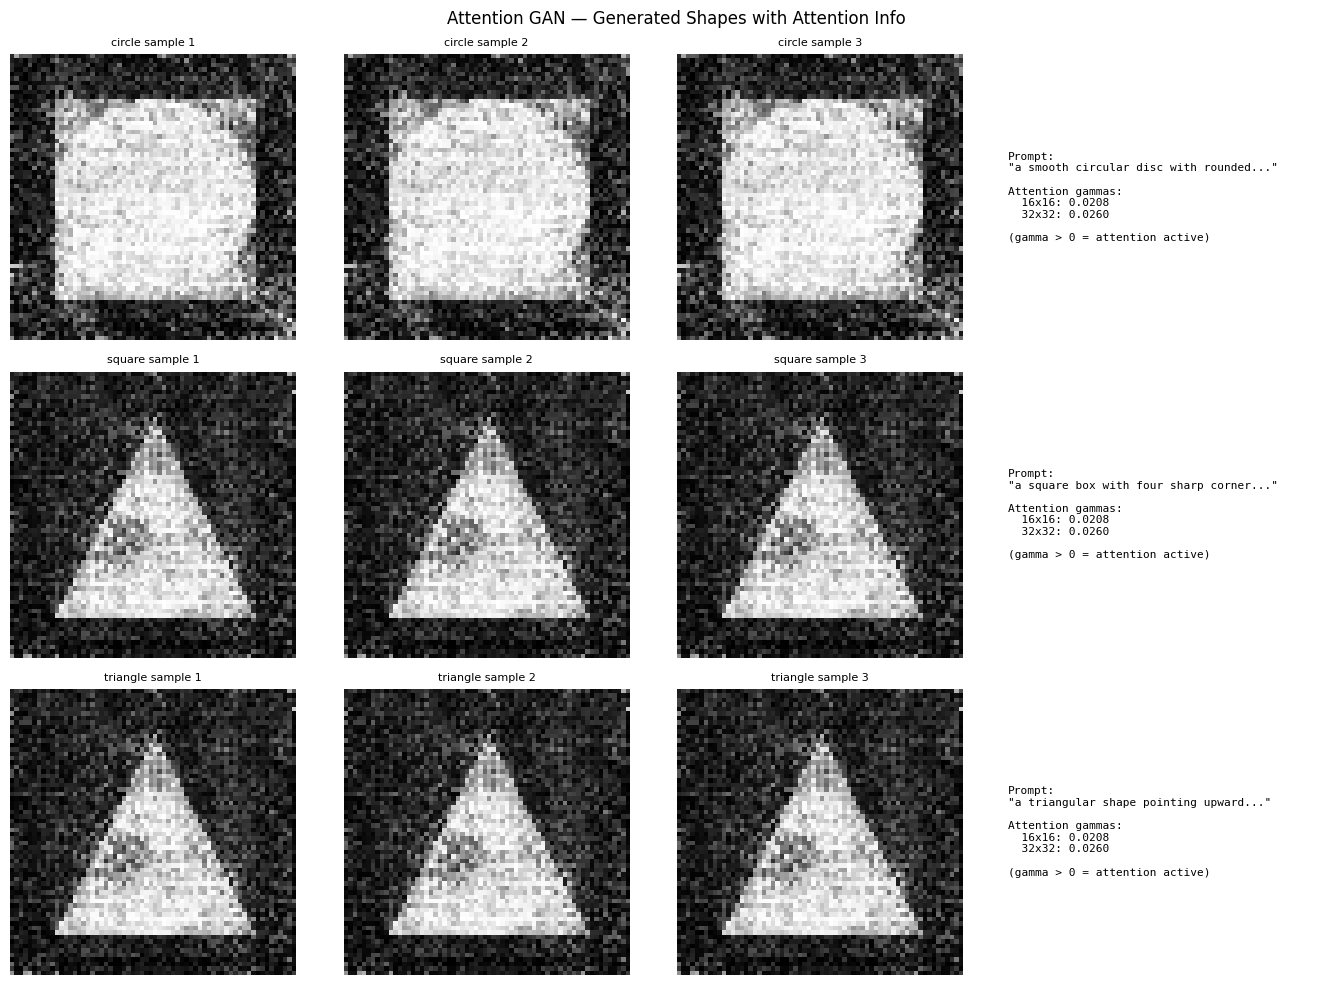

Done!


In [9]:
# CELL 9: Visualize Attention Maps


def get_attention_map(text_prompt: str):
    """
    Hook into the self-attention of attn2 (32x32 scale)
    to visualize what spatial regions attend to each other.
    """
    attention_weights = {}

    def hook_fn(module, input, output):

        pass

    emb  = get_text_embedding(text_prompt)
    emb_t = torch.tensor(emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    noise = torch.randn(1, LATENT_DIM).to(DEVICE)

    G.eval()
    with torch.no_grad():
        img = G(noise, emb_t).cpu()

    return img.squeeze().numpy()



print('Generating comparison samples...')

test_prompts = [
    ('circle', 'a smooth circular disc with rounded edges'),
    ('square', 'a square box with four sharp corners'),
    ('triangle', 'a triangular shape pointing upward')
]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for row, (shape, prompt) in enumerate(test_prompts):
    emb   = get_text_embedding(prompt)
    emb_t = torch.tensor(emb, dtype=torch.float32).unsqueeze(0).repeat(3, 1).to(DEVICE)
    noise = torch.randn(3, LATENT_DIM).to(DEVICE)

    G.eval()
    with torch.no_grad():
        imgs = G(noise, emb_t).cpu()

    for col in range(3):
        axes[row][col].imshow(imgs[col].squeeze(), cmap='gray')
        axes[row][col].set_title(f'{shape} sample {col+1}', fontsize=8)
        axes[row][col].axis('off')


    gamma1 = G.attn1.cross_attn.gamma.item()
    gamma2 = G.attn2.cross_attn.gamma.item()
    info_text = (
        f'Prompt:\n"{prompt[:35]}..."\n\n'
        f'Attention gammas:\n'
        f'  16x16: {gamma1:.4f}\n'
        f'  32x32: {gamma2:.4f}\n\n'
        f'(gamma > 0 = attention active)'
    )
    axes[row][3].text(0.05, 0.5, info_text, transform=axes[row][3].transAxes,
                      fontsize=8, verticalalignment='center', fontfamily='monospace')
    axes[row][3].axis('off')

plt.suptitle('Attention GAN — Generated Shapes with Attention Info', fontsize=12)
plt.tight_layout()
plt.show()
print('Done!')

In [ ]:
# CELL 10: Save Models
from google.colab import drive
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/Project_Datasets/Q2_AttentionGAN'
os.makedirs(save_dir, exist_ok=True)
torch.save(G.state_dict(), f'{save_dir}/attention_generator.pth')
torch.save(D.state_dict(), f'{save_dir}/attention_discriminator.pth')
print(f'Saved to {save_dir}')

Mounted at /content/drive


NameError: name 'os' is not defined

In [ ]:
# CELL 11: Gradio UI
import gradio as gr

def generate_with_attention(prompt: str, num_samples: int):
    if not prompt.strip():
        return None, 'Please enter a description!'
    try:
        cleaned  = preprocess_text(prompt)
        emb      = get_text_embedding(cleaned)
        emb_t    = torch.tensor(emb, dtype=torch.float32)
        emb_batch = emb_t.unsqueeze(0).repeat(int(num_samples), 1).to(DEVICE)
        noise    = torch.randn(int(num_samples), LATENT_DIM).to(DEVICE)

        G.eval()
        with torch.no_grad():
            imgs = G(noise, emb_batch).cpu()

        imgs_np   = ((imgs.squeeze(1).numpy() + 1) / 2 * 255).astype(np.uint8)
        grid_size = int(np.ceil(np.sqrt(int(num_samples))))
        grid      = np.zeros((grid_size * IMG_SIZE, grid_size * IMG_SIZE), dtype=np.uint8)
        for i, img in enumerate(imgs_np):
            r, c = i // grid_size, i % grid_size
            grid[r*IMG_SIZE:(r+1)*IMG_SIZE, c*IMG_SIZE:(c+1)*IMG_SIZE] = img

        pil_img = Image.fromarray(grid)

        gamma_cross1 = G.attn1.cross_attn.gamma.item()
        gamma_self1  = G.attn1.self_attn.gamma.item()
        gamma_cross2 = G.attn2.cross_attn.gamma.item()
        gamma_self2  = G.attn2.self_attn.gamma.item()

        info = f"""ATTENTION GAN PIPELINE:
{'='*45}
Input prompt   : "{prompt}"
Cleaned text   : "{cleaned}"
Embedding shape: {emb.shape} (512D CLIP)
Detected shape : {LABELS[extract_shape_label(prompt)]}

ATTENTION WEIGHTS (gamma values):
  Attention at 16x16 scale:
    CrossAttention gamma : {gamma_cross1:.6f}
    SelfAttention  gamma : {gamma_self1:.6f}
  Attention at 32x32 scale:
    CrossAttention gamma : {gamma_cross2:.6f}
    SelfAttention  gamma : {gamma_self2:.6f}

HOW ATTENTION HELPS:
  CrossAttention: each pixel attends to text
  SelfAttention : each pixel attends to all others
  Result: globally consistent, text-aligned shapes

Samples generated: {num_samples}
Device: {DEVICE}
"""
        return pil_img, info
    except Exception as e:
        return None, f'Error: {str(e)}'


with gr.Blocks(title='Attention GAN', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # Q2: Attention-Enhanced Text-to-Image GAN
    ### Self-Attention + Cross-Attention for better text alignment
    """)

    with gr.Row():
        with gr.Column(scale=1):
            prompt_in   = gr.Textbox(
                label='Text Description',
                value='a smooth circular disc with rounded edges',
                lines=3
            )
            num_samples = gr.Slider(1, 9, 4, step=1, label='Samples')
            gen_btn     = gr.Button('Generate', variant='primary', size='lg')

            gr.Markdown('### Quick Examples')
            examples = [
                'a smooth circular disc with rounded edges',
                'a square box with sharp right angles',
                'a triangular pyramid pointing upward',
            ]
            for ex in examples:
                gr.Button(ex[:40]).click(lambda e=ex: e, outputs=prompt_in)

            gr.Markdown("""
            ### What attention adds:
            - **Cross-attention**: generator reads text at each spatial position
            - **Self-attention**: generator maintains global spatial consistency
            - **Gamma**: learnable weight — how much attention contributes
            """)

        with gr.Column(scale=2):
            output_img  = gr.Image(label='Generated Image', type='pil', height=300)
            output_info = gr.Textbox(label='Attention Pipeline Info', lines=22, interactive=False)

    gen_btn.click(
        fn=generate_with_attention,
        inputs=[prompt_in, num_samples],
        outputs=[output_img, output_info]
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c30cc327166c3d0a86.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c30cc327166c3d0a86.gradio.live
